In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_theme(style="whitegrid")

In [3]:
from pathlib import Path
BASE_DIR = Path.cwd().parent

RAW_DATA = BASE_DIR / "data" / "raw"
PROCESSED_DATA = BASE_DIR / "data" / "processed"

In [4]:
fund_master = pd.read_csv(
    RAW_DATA / "01_fund_master.csv"
)

nav_history = pd.read_csv(
    PROCESSED_DATA / "nav_history_cleaned.csv"
)

scheme_performance = pd.read_csv(
    PROCESSED_DATA / "scheme_performance_cleaned.csv"
)

investor_transactions = pd.read_csv(
    PROCESSED_DATA / "investor_transactions_cleaned.csv"
)

aum_by_fund_house = pd.read_csv(
    RAW_DATA / "03_aum_by_fund_house.csv"
)

monthly_sip_inflows = pd.read_csv(
    RAW_DATA / "04_monthly_sip_inflows.csv"
)

category_inflows = pd.read_csv(
    RAW_DATA / "05_category_inflows.csv"
)

industry_folio_count = pd.read_csv(
    RAW_DATA / "06_industry_folio_count.csv"
)

portfolio_holdings = pd.read_csv(
    RAW_DATA / "09_portfolio_holdings.csv"
)

In [5]:
# NAV Trend Analysis
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    opacity=0.15,
    fillcolor="green",
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    opacity=0.15,
    fillcolor="red",
    line_width=0
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="amfi_code"
)

fig.show()

In [6]:
#AUM growth bar chart

aum_by_fund_house["date"] = pd.to_datetime(
    aum_by_fund_house["date"]
)

aum_by_fund_house["year"] = (
    aum_by_fund_house["date"].dt.year
)

aum_yearly = (
    aum_by_fund_house
    .groupby(["year", "fund_house"])["aum_crore"]
    .max()
    .reset_index()
)

aum_yearly.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,285000
1,2022,Axis Mutual Fund,250000
2,2022,DSP Mutual Fund,112000
3,2022,HDFC Mutual Fund,445000
4,2022,ICICI Prudential MF,488000


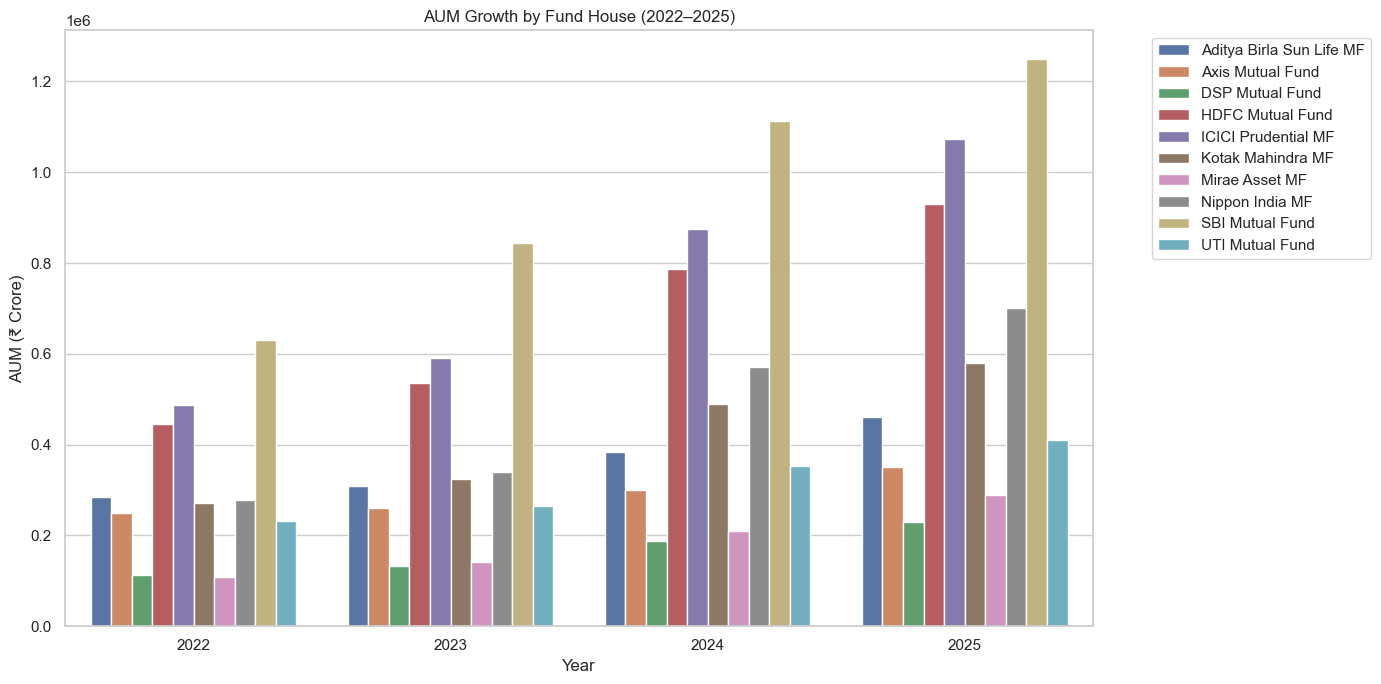

In [7]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [8]:
sbi_aum = aum_yearly[
    aum_yearly["fund_house"].str.contains(
        "SBI",
        case=False,
        na=False
    )
]

sbi_aum

,year,fund_house,aum_crore
8,2022,SBI Mutual Fund,630000
18,2023,SBI Mutual Fund,845000
28,2024,SBI Mutual Fund,1114000
38,2025,SBI Mutual Fund,1250000


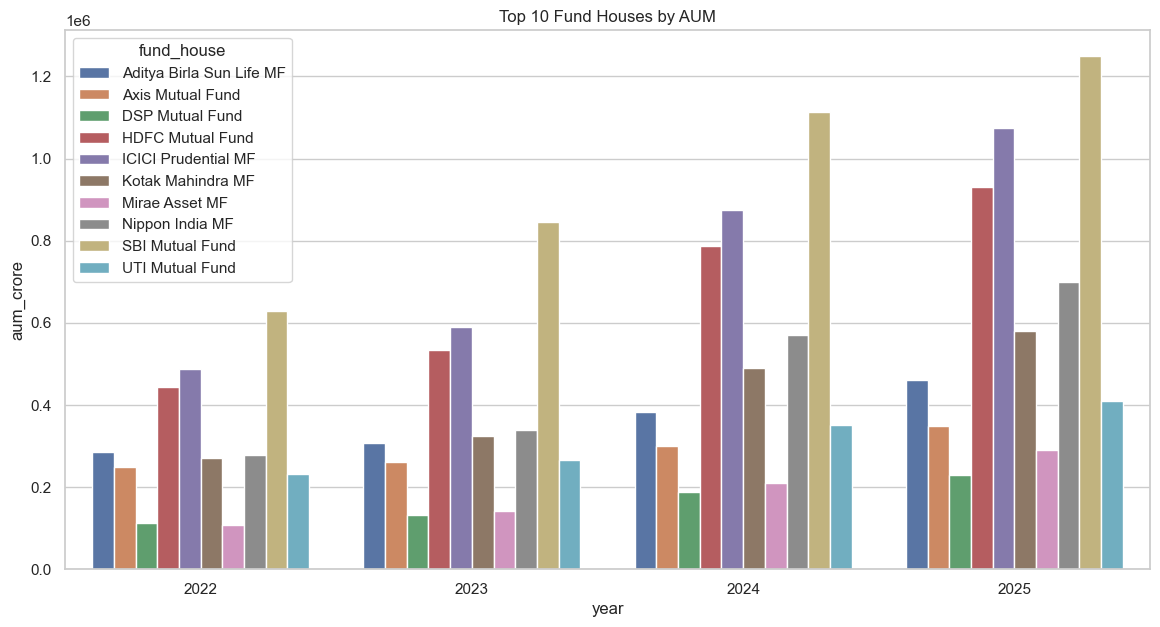

In [9]:
top_funds = (
    aum_yearly.groupby("fund_house")["aum_crore"]
    .max()
    .nlargest(10)
    .index
)

aum_top10 = aum_yearly[
    aum_yearly["fund_house"].isin(top_funds)
]

plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_top10,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("Top 10 Fund Houses by AUM")
plt.show()

In [10]:
#SIP inflow time-series
monthly_sip_inflows["month"] = pd.to_datetime(
    monthly_sip_inflows["month"]
)

In [11]:
import plotly.express as px

fig = px.line(
    monthly_sip_inflows,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [12]:
max_row = monthly_sip_inflows.loc[
    monthly_sip_inflows["sip_inflow_crore"].idxmax()
]

fig = px.line(
    monthly_sip_inflows,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [13]:
#Category inflow heatmap
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [17]:
category_inflows["month"] = pd.to_datetime(
    category_inflows["month"]
)

category_inflows["month"] = (
    category_inflows["month"]
    .dt.strftime("%b-%Y")
)

In [19]:
heatmap_data = category_inflows.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

heatmap_data.head()

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


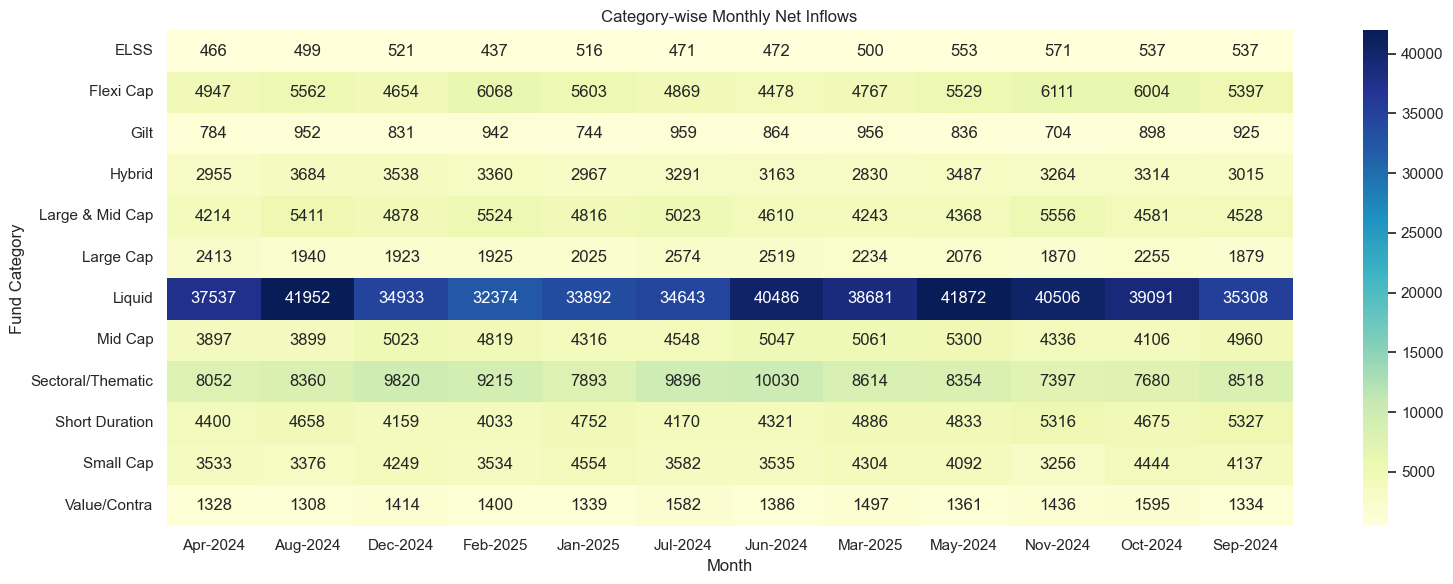

In [20]:
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

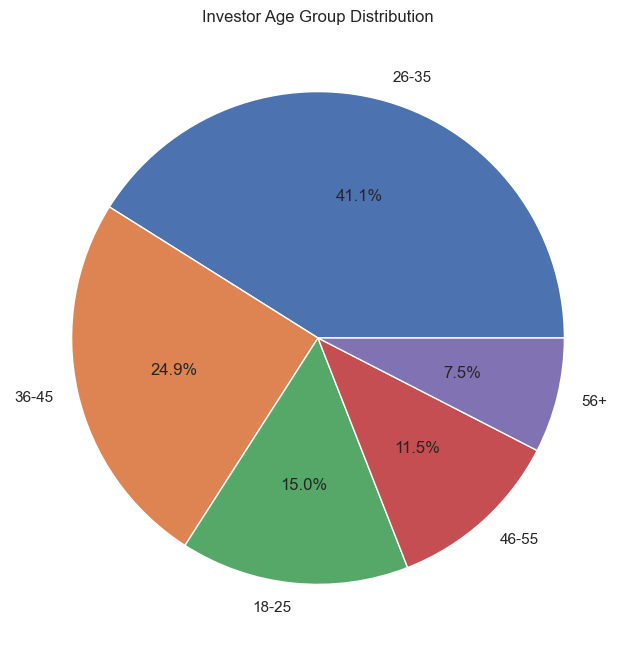

In [25]:
# Investor Demographics Analysis
plt.figure(figsize=(8,8))

investor_transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

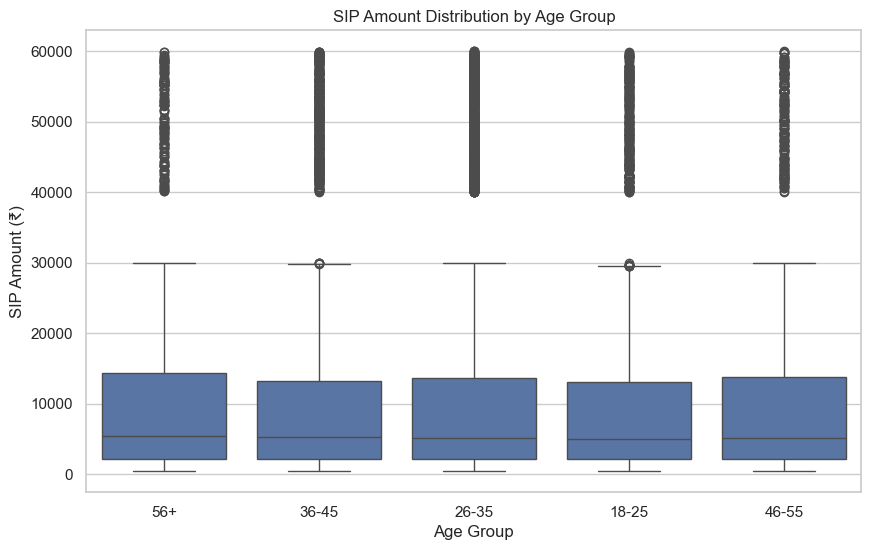

In [26]:
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.show()

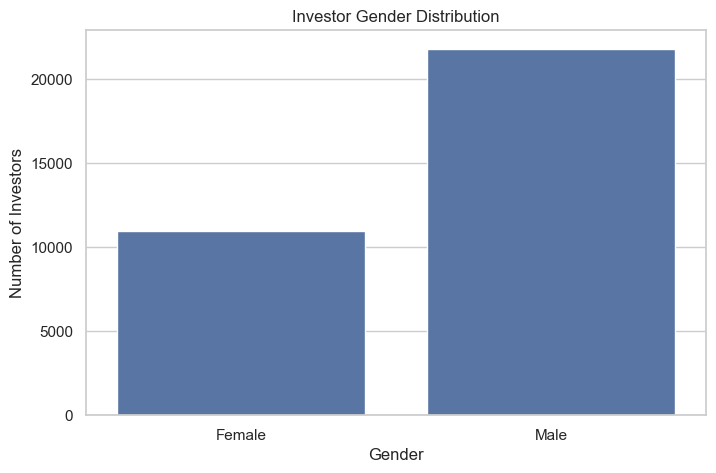

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor_transactions,
    x="gender"
)

plt.title("Investor Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.show()

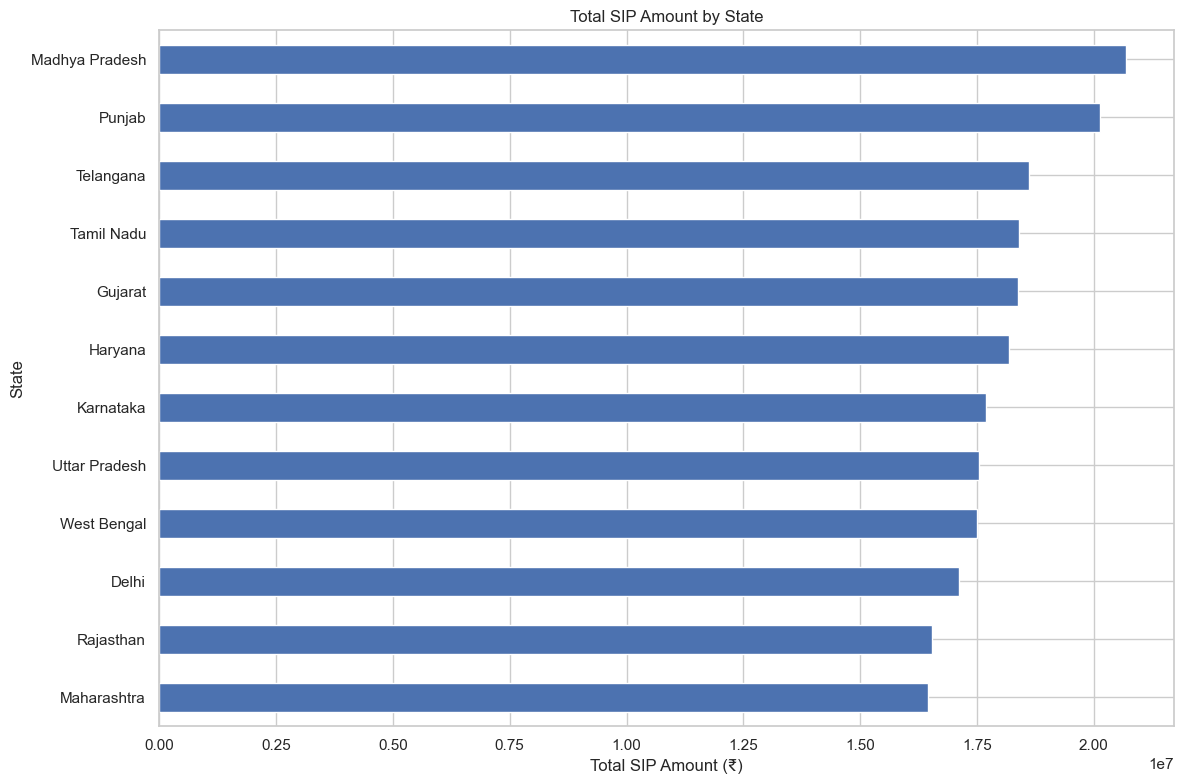

In [28]:
# Geographic Distribution Analysis
sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
]

state_sip = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

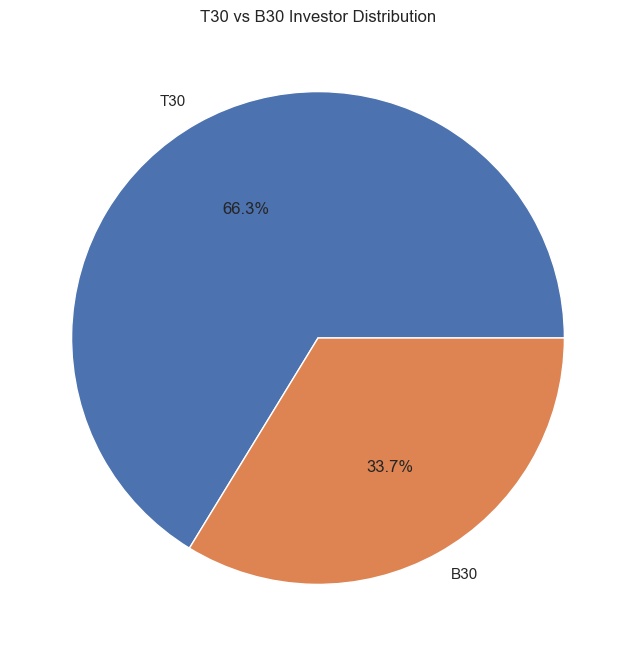

In [32]:
plt.figure(figsize=(8,8))

city_tier_counts = (
    investor_transactions["city_tier"]
    .value_counts()
)

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [33]:
city_tier_counts = (
    investor_transactions["city_tier"]
    .value_counts(normalize=True)
    * 100
)

print(city_tier_counts)

city_tier
T30    66.260907
B30    33.739093
Name: proportion, dtype: float64


In [35]:
# Folio Count Growth Analysis
print(industry_folio_count.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [36]:
industry_folio_count["month"] = pd.to_datetime(
    industry_folio_count["month"]
)

In [39]:
first_row = industry_folio_count.iloc[0]
last_row = industry_folio_count.iloc[-1]

fig = px.line(
    industry_folio_count,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Count Growth (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x=first_row["month"],
    y=first_row["total_folios_crore"],
    text=f"{first_row['total_folios_crore']:.2f} Cr",
    showarrow=True
)

fig.add_annotation(
    x=last_row["month"],
    y=last_row["total_folios_crore"],
    text=f"{last_row['total_folios_crore']:.2f} Cr",
    showarrow=True
)
milestone = industry_folio_count[
    industry_folio_count["total_folios_crore"] >= 20
].iloc[0]

fig.add_annotation(
    x=milestone["month"],
    y=milestone["total_folios_crore"],
    text="20 Cr Milestone",
    showarrow=True,
    arrowhead=2
)

fig.show()

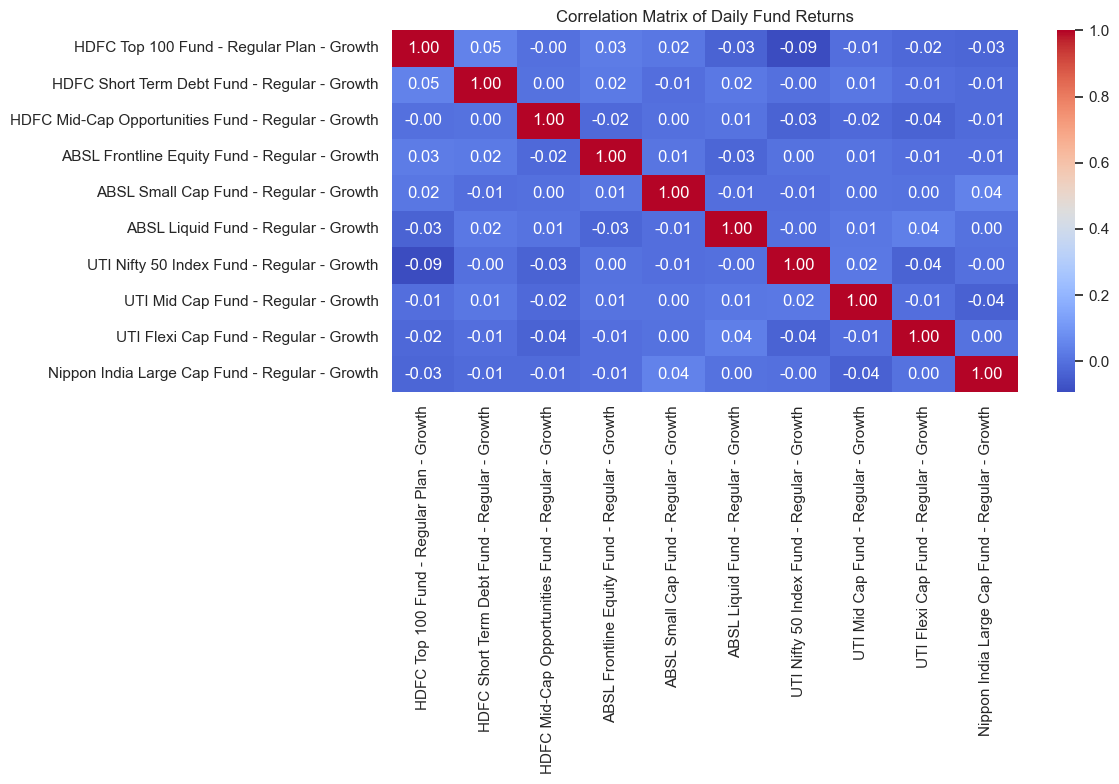

In [41]:
# NAV Return Correlation Matrix
# Select 10 funds
top10_funds = nav_history["amfi_code"].unique()[:10]

# Create NAV matrix
nav_matrix = (
    nav_history[
        nav_history["amfi_code"].isin(top10_funds)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

# Calculate daily returns
daily_returns = nav_matrix.pct_change()

# Correlation matrix
corr_matrix = daily_returns.corr()

# Map AMFI codes to scheme names
name_map = dict(
    zip(
        fund_master["amfi_code"],
        fund_master["scheme_name"]
    )
)

corr_matrix.columns = [
    name_map.get(col, col)
    for col in corr_matrix.columns
]

corr_matrix.index = [
    name_map.get(idx, idx)
    for idx in corr_matrix.index
]

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily Fund Returns")

plt.tight_layout()

plt.show()

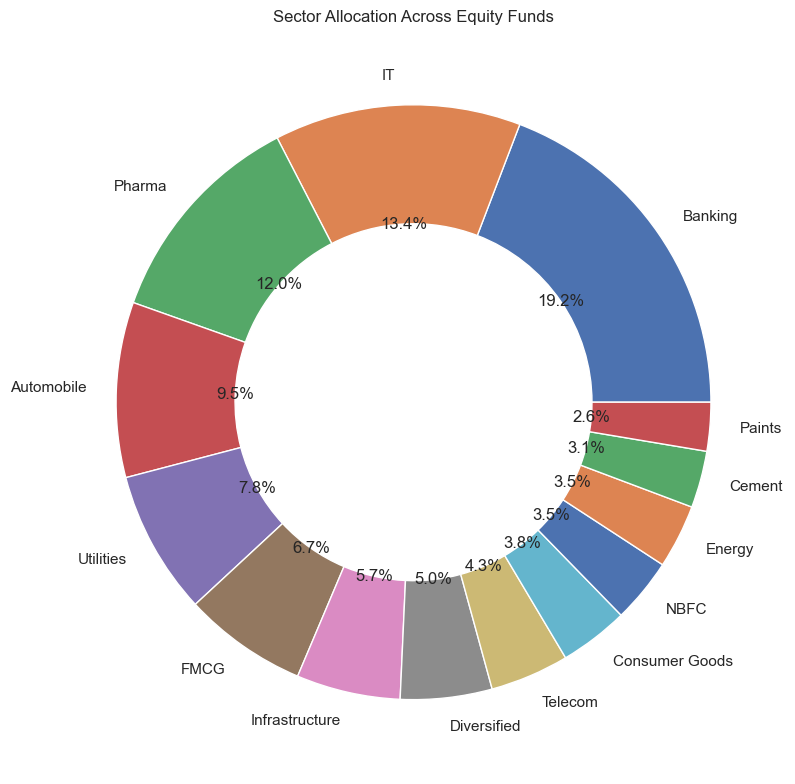

In [44]:
#Sector allocation donut

# Aggregate sector weights across all equity funds
sector_allocation = (
    portfolio_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Donut chart
plt.figure(figsize=(10, 8))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()